In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [2]:
DATASET_PATH = Path() / "dataset"

# Zadanie 1

Populacja Stanów Zjednoczonych na przestrzeni lat przedstawiała się następująco:
| Rok  | Populacja |
|------|-----------|
| 1900 | 76212168  |
| 1910 | 92228496  |
| 1920 | 106021537 |
| 1930 | 123202624 |
| 1940 | 132164569 |
| 1950 | 151325798 |
| 1960 | 179323175 |
| 1970 | 203302031 |
| 1980 | 226542199 |

Istnieje dokładnie jeden wielomian ósmego stopnia, który interpoluje powyższe dziewięć punktów, natomiast sam wielomian może być reprezentowany na różne sposoby. 

Rozważamy następujące zbiory funkcji bazowych $\phi_j(t), \ j = 1, ..., 9$:
$$ \phi_j(t) = t^{j-1} \tag{1} $$
$$ \phi_j(t) = (t - 1900)^{j-1} \tag{2} $$
$$ \phi_j(t) = (t - 1940)^{j-1} \tag{3} $$
$$ \phi_j(t) = ((t - 1940)/40)^{j-1} \tag{4} $$

In [3]:
df_population = pd.read_csv(DATASET_PATH / r"population.dat", header=0)
np_population = df_population.values
df_population

,Rok,Populacja
0,1900,76212168
1,1910,92228496
2,1920,106021537
3,1930,123202624
4,1940,132164569
5,1950,151325798
6,1960,179323175
7,1970,203302031
8,1980,226542199


In [4]:
def phi1(t, j):
    return t ** (j - 1)


def phi2(t, j):
    return (t - 1900) ** (j - 1)


def phi3(t, j):
    return (t - 1940) ** (j - 1)


def phi4(t, j):
    return ((t - 1940) / 40) ** (j - 1)

### a)
Dla każdego z czterech zbiorów funkcji bazowych utwórz macierz Vandermonde’a.

In [5]:
def create_vandermonde_matrix(phi, years, j_max=9):
    # np.vectorize(phi)(year, 2), because np.vander() wants a 1D array of x^1
    # and uses N as the number of columns in the output matrix
    vphi = np.vectorize(phi, otypes=[np.float64])
    return np.vander(vphi(years, 2), N=j_max, increasing=True)

In [6]:
phi1_matrix = create_vandermonde_matrix(phi1, np_population[:, 0])
phi2_matrix = create_vandermonde_matrix(phi2, np_population[:, 0])
phi3_matrix = create_vandermonde_matrix(phi3, np_population[:, 0])
phi4_matrix = create_vandermonde_matrix(phi4, np_population[:, 0])

### b)
Oblicz współczynnik uwarunkowania każdej z powyższch macierzy, używając funkcji `numpy.linalg.cond`.

In [7]:
phi1_cond = np.linalg.cond(phi1_matrix)
phi2_cond = np.linalg.cond(phi2_matrix)
phi3_cond = np.linalg.cond(phi3_matrix)
phi4_cond = np.linalg.cond(phi4_matrix)

In [8]:
df_conds = pd.DataFrame(
    {
        "phi_number": [1, 2, 3, 4],
        "phi": [phi1, phi2, phi3, phi4],
        "phi_matrix": [phi1_matrix, phi2_matrix, phi3_matrix, phi4_matrix],
        "cond": [phi1_cond, phi2_cond, phi3_cond, phi4_cond],
    }
)

In [9]:
df_conds[["phi_number", "cond"]].style.hide(axis="index").format({"cond": "{:.2e}"})

phi_number,cond
1,9.62e+36
2,5.87e+15
3,9.32e+12
4,1.61e+03


### c)
Używając najlepiej uwarunkowanej bazy wielomianów, znajdź współczynniki wielomianu interpolacyjnego dla danych z zadania. Narysuj wielomian interpolacyjny. 
W tym celu użyj schematu Hornera i oblicz na przedziale [1900,1990] wartości wielomianu w odstępach jednorocznych. Na wykresie umieść także węzły interpolacji.


In [10]:
# get the phi with the lowest condition number
phi_number, phi, phi_matrix, cond = df_conds.loc[df_conds["cond"].idxmin()]
vphi = np.vectorize(phi, otypes=[np.float64])

In [11]:
# interpolation polynomial coefficients [x^n, x^(n-1), ..., x^0]
interpolation_polynomial = np.linalg.solve(phi_matrix, np_population[:, 1])[::-1]

In [12]:
pd.DataFrame(
    {
        "coefficient_number": np.arange(len(interpolation_polynomial) - 1, -1, -1),
        "coefficient": interpolation_polynomial,
    }
).style.hide(axis="index").format({"coefficient": "{:.2e}"})

coefficient_number,coefficient
8,-3.15e+08
7,1.89e+08
6,6.06e+08
5,-3.43e+08
4,-3.75e+08
3,1.83e+08
2,1.03e+08
1,4.61e+07
0,1.32e+08


In [13]:
interpolation_years = np.arange(1900, 1991, 1)
interpolation_values = np.polyval(
    interpolation_polynomial, vphi(interpolation_years, 2)
)

In [14]:
df_c = pd.DataFrame(
    {
        "interpolation_years": interpolation_years,
        "interpolation_values": interpolation_values,
    }
)
df_c[interpolation_years % 5 == 0].style.hide(axis="index").format(
    {"interpolation_values": "{:.0f}"}
)

interpolation_years,interpolation_values
1900,76212168
1905,93842317
1910,92228496
1915,96163928
1920,106021537
1925,116183066
1930,123202624
1935,127567870
1940,132164569
1945,139792824


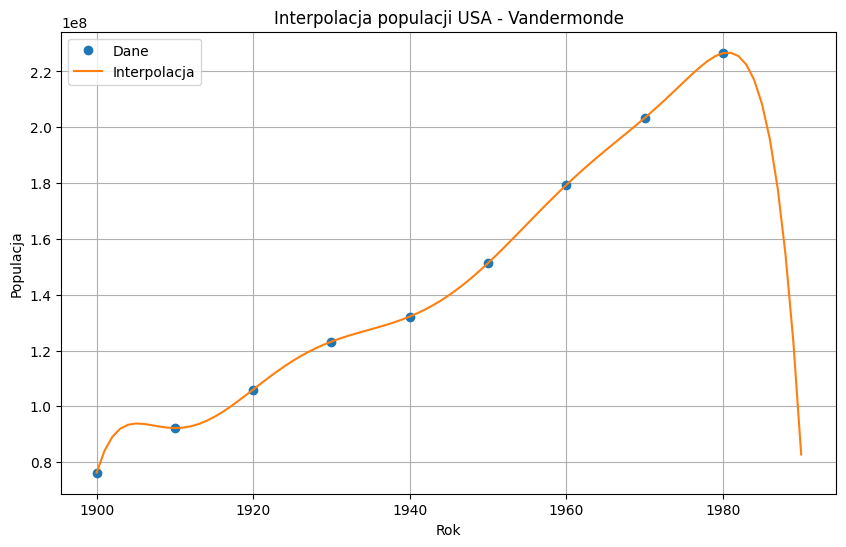

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(np_population[:, 0], np_population[:, 1], "o", label="Dane")
plt.plot(interpolation_years, interpolation_values, label="Interpolacja")
plt.xlabel("Rok")
plt.ylabel("Populacja")
plt.title("Interpolacja populacji USA - Vandermonde")
plt.grid(True)
plt.legend()
plt.show()

### d)
Dokonaj ekstrapolacji wielomianu do roku 1990. Porównaj otrzymaną wartość z prawdziwą wartością dla roku 1990, wynoszącą 248 709 873. Ile wynosi błąd względny ekstrapolacji dla roku 1990?


In [16]:
data_in_1990 = 248_709_873
interpolation_in_1990 = np.polyval(interpolation_polynomial, vphi(1990, 2))

interpolation_in_1990_relative_error = (
    abs(data_in_1990 - interpolation_in_1990) / data_in_1990
)

In [17]:
pd.DataFrame(
    {
        "data_in_1990": data_in_1990,
        "interpolation_in_1990": f"{interpolation_in_1990:.0f}",
        "relative_error": f"{100 * interpolation_in_1990_relative_error:.2f}%",
    },
    index=[0],
).style.hide(axis="index")

data_in_1990,interpolation_in_1990,relative_error
248709873,82749141,66.73%


### e)
Wyznacz wielomian interpolacyjny Lagrange’a na podstawie 9 węzłów interpolacji podanych w zadaniu. Oblicz wartości wielomianu w odstępach jednorocznych.

In [18]:
def lagrange_interpolation(x, xs, ys):
    def L(k, x):
        result = 1
        for i, xi in enumerate(xs):
            if i != k:
                result *= (x - xi) / (xs[k] - xi)
        return result

    def P(x):
        result = 0
        for k in range(len(xs)):
            result += ys[k] * L(k, x)
        return result

    return P(x)

In [19]:
interpolation_years = np.arange(1900, 1981, 1)
interpolation_values = lagrange_interpolation(
    interpolation_years, np_population[:, 0], np_population[:, 1]
)

In [20]:
pd.DataFrame(
    {
        "interpolation_years": interpolation_years,
        "interpolation_values": interpolation_values,
    }
)[interpolation_years % 5 == 0].style.hide(axis="index").format(
    {"interpolation_values": "{:.0f}"}
)

interpolation_years,interpolation_values
1900,76212168
1905,93842317
1910,92228496
1915,96163928
1920,106021537
1925,116183066
1930,123202624
1935,127567870
1940,132164569
1945,139792824


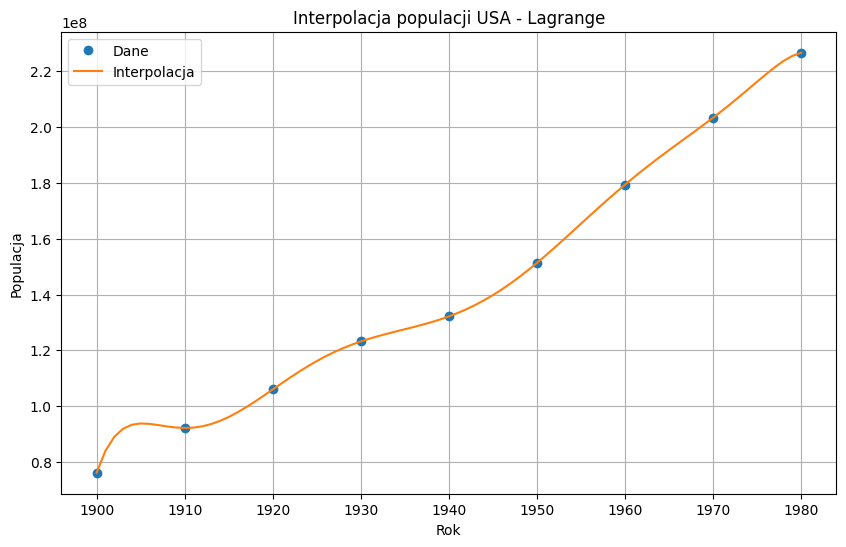

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(np_population[:, 0], np_population[:, 1], "o", label="Dane")
plt.plot(interpolation_years, interpolation_values, label="Interpolacja")
plt.xlabel("Rok")
plt.ylabel("Populacja")
plt.title("Interpolacja populacji USA - Lagrange")
plt.grid(True)
plt.legend()
plt.show()

### f)
Wyznacz wielomian interpolacyjny Newtona na podstawie tych samych węzłów interpolacji i oblicz wartości wielomianu w odstępach jednorocznych.

In [22]:
def divided_diff(x, y):
    """
    function to calculate the divided
    differences table
    """
    n = len(y)
    coef = np.zeros([n, n])
    # the first column is y
    coef[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i + 1][j - 1] - coef[i][j - 1]) / (x[i + j] - x[i])

    return coef


def newton_poly(coef, x_data, x):
    """
    evaluate the newton polynomial
    at x
    """
    n = len(x_data) - 1
    p = coef[n]
    for k in range(1, n + 1):
        p = coef[n - k] + (x - x_data[n - k]) * p
    return p

In [23]:
x = np_population[:, 0]
y = np_population[:, 1]
# get the divided difference
a_s = divided_diff(x, y)[0, :]

interpolation_values = newton_poly(a_s, x, interpolation_years)

In [24]:
pd.DataFrame(
    {
        "interpolation_years": interpolation_years,
        "interpolation_values": interpolation_values,
    }
)[interpolation_years % 5 == 0].style.hide(axis="index").format(
    {"interpolation_values": "{:.0f}"}
)

interpolation_years,interpolation_values
1900,76212168
1905,93842317
1910,92228496
1915,96163928
1920,106021537
1925,116183066
1930,123202624
1935,127567870
1940,132164569
1945,139792824


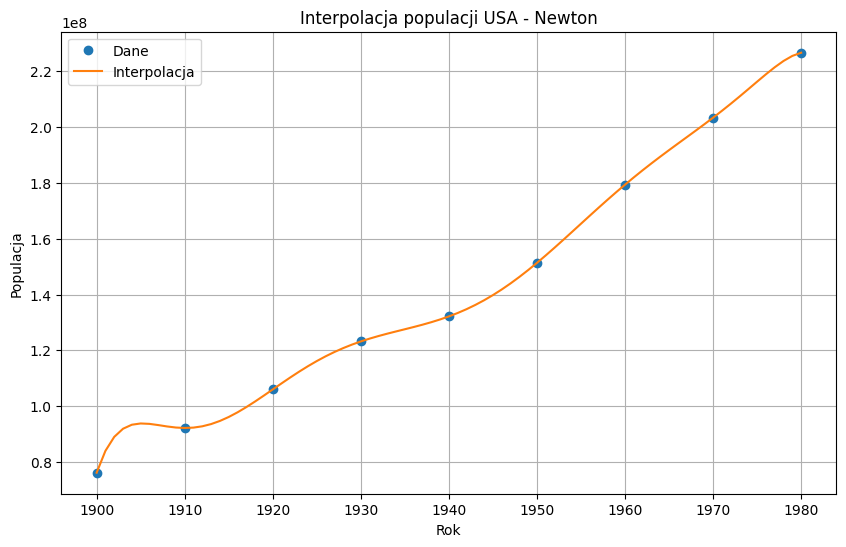

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(np_population[:, 0], np_population[:, 1], "o", label="Dane")
plt.plot(interpolation_years, interpolation_values, label="Interpolacja")
plt.xlabel("Rok")
plt.ylabel("Populacja")
plt.title("Interpolacja populacji USA - Newton")
plt.grid(True)
plt.legend()
plt.show()

### g)
Zaokrąglij dane podane w tabeli do jednego miliona. Na podstawie takich danych wyznacz wielomian interpolacyjny ósmego stopnia, używając najlepiej uwarunkowanej bazy z podpunktu (c). Porównaj wyznaczone współczynniki z współczynnikami obliczonymi w podpunkcie (c). Wyjaśnij otrzymany wynik.


In [26]:
# get the phi with the lowest condition number
phi_number, phi, phi_matrix, cond = df_conds.loc[df_conds["cond"].idxmin()]
vphi = np.vectorize(phi, otypes=[np.float64])

In [27]:
# interpolation polynomial coefficients [x^n, x^(n-1), ..., x^0]
interpolation_polynomial = np.linalg.solve(
    phi_matrix, np.round(np_population[:, 1], -6)
)[::-1]

In [28]:
pd.DataFrame(
    {
        "coefficient_number": np.arange(len(interpolation_polynomial) - 1, -1, -1),
        "coefficient": interpolation_polynomial,
    }
).style.hide(axis="index").format({"coefficient": "{:.2e}"})

coefficient_number,coefficient
8,-2.94e+08
7,1.87e+08
6,5.70e+08
5,-3.38e+08
4,-3.57e+08
3,1.81e+08
2,1.00e+08
1,4.60e+07
0,1.32e+08


In [29]:
interpolation_years = np.arange(1900, 1991, 1)
interpolation_values = np.polyval(
    interpolation_polynomial, vphi(interpolation_years, 2)
)

In [30]:
data_values = np.full(interpolation_years.size, np.nan)
data_values[::10] = np.append(np_population[:, 1], data_in_1990)
pd.DataFrame(
    {
        "interpolation_years": interpolation_years,
        "data_values": data_values,
        "round_interpolation_values": interpolation_values,
        "relative_error_round": 100
        * (
            abs(interpolation_values - data_values)
            / data_values
        ),
        "interpolation_values": df_c["interpolation_values"],
        "relative_error": 100
        * (
            abs(df_c["interpolation_values"] - data_values)
            / data_values
        ),
    }
)[interpolation_years % 10 == 0].style.hide(axis="index").format(
    {
        "data_values": "{:.0f}",
        "round_interpolation_values": "{:.0f}",
        "relative_error_round": "{:.2f}%",
        "interpolation_values": "{:.0f}",
        "relative_error": "{:.2f}%",
    }
)

interpolation_years,data_values,round_interpolation_values,relative_error_round,interpolation_values,relative_error
1900,76212168,76000000,0.28%,76212168,0.00%
1910,92228496,92000000,0.25%,92228496,0.00%
1920,106021537,106000000,0.02%,106021537,0.00%
1930,123202624,123000000,0.16%,123202624,0.00%
1940,132164569,132000000,0.12%,132164569,0.00%
1950,151325798,151000000,0.22%,151325798,0.00%
1960,179323175,179000000,0.18%,179323175,0.00%
1970,203302031,203000000,0.15%,203302031,0.00%
1980,226542199,227000000,0.20%,226542199,0.00%
1990,248709873,109000000,56.17%,82749141,66.73%
